# 03 · Lighting schedules and energy impact

Run after `02_Model_Training.ipynb`. This notebook links the saved radiation model to the 10 locations, evaluates three daylight scenarios, proposes ON/OFF intervals and compares energy consumption with the 20 observed manual intervals.

**All recommended schedules are conditional prototype scenarios requiring review.** No local measured lux or current weather feed is available. Code: `src/lighting.py`; editable settings: `config/lighting_policy.json`.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT/'config/project_config.json').exists():
    ROOT = ROOT/'LightSync'
assert (ROOT/'config/project_config.json').exists(), 'Open from the LightSync project folder.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
(ROOT/'reports/figures').mkdir(parents=True, exist_ok=True)


## 1. Inspect the daylight settings

Daylight proxy: `predicted radiation × luminous efficacy × obstruction transmission`.

Transmission and efficacy values are uncalibrated sensitivity settings, not measured attenuation. The thresholds are demonstration values, not claimed lighting standards. A lower-daylight scenario means less light reaches the task area, potentially requiring earlier ON or later OFF. A roof/covered label alone cannot describe every corridor's windows or depth.

The radiation proxy cannot reliably resolve twilight lux. Sunset/sunrise guards keep lights ON through the night. Shape-preserving PCHIP interpolation evaluates the 15-minute model profile on a **one-minute decision grid**. This provides finer decisions, not new measured information or one-minute prediction accuracy.

In [2]:
policy = json.loads((ROOT/'config/lighting_policy.json').read_text())
cfg = json.loads((ROOT/'config/project_config.json').read_text())
display(pd.DataFrame(policy['daylight_transfer']).T)
display(pd.DataFrame(policy['thresholds_lux']).T.rename(columns={'on':'ON threshold (lux)','off':'OFF threshold (lux)'}))
print('Scenario interpretation:',policy['scenario_interpretation'])
print('Tariff:',cfg['electricity_tariff_inr_per_kwh'],'; carbon factor:',cfg['grid_emission_factor_kg_co2_per_kwh'])


,lower_daylight,central,higher_daylight
Open sky / none,0.80,1.00,1.00
Sparse trees,0.40,0.65,0.85
Dense trees,0.10,0.25,0.50
Mixed obstructions,0.20,0.40,0.70
Building shade,0.08,0.20,0.40
Roof / covered,0.02,0.05,0.15


,ON threshold (lux),OFF threshold (lux)
outdoor_road,20,30
corridor,100,150


Scenario interpretation: Sensitivity combinations, not confidence intervals or measured site attenuation.
Tariff: None ; carbon factor: None


## 2. Generate schedules

For each observed night, predict and interpolate a noon-to-noon daylight profile. Choose the latest ON that covers every modelled evening deficit, or no later than sunset. Choose the earliest OFF after sunrise for which the remaining morning profile stays above its threshold. A five-minute lookahead checks stability without wasting a full sampling interval, and two-minute buffers protect transition boundaries. This is the shortest feasible single overnight interval under the specified proxy and constraints; it is not a globally or physically validated optimum. Manual endpoint observations reconstruct one continuous ON interval and presume OFF outside it; no continuous logger verified this reconstruction.

This is a single overnight-interval demonstration. Unexpected daytime darkness, outages or rapid real weather changes need a live sensing/forecast controller. Always-dark corridors require site review, not forced switching-off.

In [3]:
from src.lighting import build_scenarios, interval_impact
tables, totals = build_scenarios(ROOT)
schedules = tables['recommended_schedules']
profiles = tables['lighting_profiles']
impacts = tables['energy_impact']
display(schedules[schedules.scenario.eq('central')][['location_name','night_start_date','manual_on_local',
    'manual_off_local','recommended_on_local','recommended_off_local','off_not_reached_within_window']])


,location_name,night_start_date,manual_on_local,manual_off_local,recommended_on_local,recommended_off_local,off_not_reached_within_window
1,IIT Road,2026-09-25,2026-09-25 16:30:00+05:30,2026-09-26 05:45:00+05:30,2026-09-25 17:16:00+05:30,2026-09-26 05:22:00+05:30,False
4,IITG Border Road,2026-09-25,2026-09-25 16:45:00+05:30,2026-09-26 05:30:00+05:30,2026-09-25 17:16:00+05:30,2026-09-26 05:25:00+05:30,False
7,Surjyamukhi Road,2026-09-25,2026-09-25 16:45:00+05:30,2026-09-26 05:30:00+05:30,2026-09-25 17:16:00+05:30,2026-09-26 05:27:00+05:30,False
10,Umiam Hostel Road,2026-09-25,2026-09-25 16:45:00+05:30,2026-09-26 05:30:00+05:30,2026-09-25 17:16:00+05:30,2026-09-26 05:23:00+05:30,False
13,KV Road,2026-09-25,2026-09-25 16:45:00+05:30,2026-09-26 05:30:00+05:30,2026-09-25 17:16:00+05:30,2026-09-26 05:27:00+05:30,False
16,Radhasura Road,2026-09-25,2026-09-25 17:00:00+05:30,2026-09-26 05:45:00+05:30,2026-09-25 17:16:00+05:30,2026-09-26 05:27:00+05:30,False
19,Godhuli Gopal Road,2026-09-25,2026-09-25 17:00:00+05:30,2026-09-26 05:30:00+05:30,2026-09-25 17:16:00+05:30,2026-09-26 05:27:00+05:30,False
22,Disang Road,2026-09-25,2026-09-25 17:00:00+05:30,2026-09-26 05:45:00+05:30,2026-09-25 17:16:00+05:30,2026-09-26 05:22:00+05:30,False
25,Lohit Hostel,2026-09-25,2026-09-25 17:00:00+05:30,2026-09-26 05:45:00+05:30,2026-09-25 16:55:00+05:30,2026-09-26 06:05:00+05:30,False
28,Disang Hostel,2026-09-25,2026-09-25 17:00:00+05:30,2026-09-26 05:45:00+05:30,2026-09-25 16:55:00+05:30,2026-09-26 06:05:00+05:30,False


## 3. Inspect one location's dusk and dawn

Change `LOCATION_ID`, `NIGHT` and `SCENARIO` below. Project location IDs are in `data/processed/locations.csv`. The plots show daylight proxies rather than measured lux. Differences are model-and-policy outputs, not verified underlighting observations.

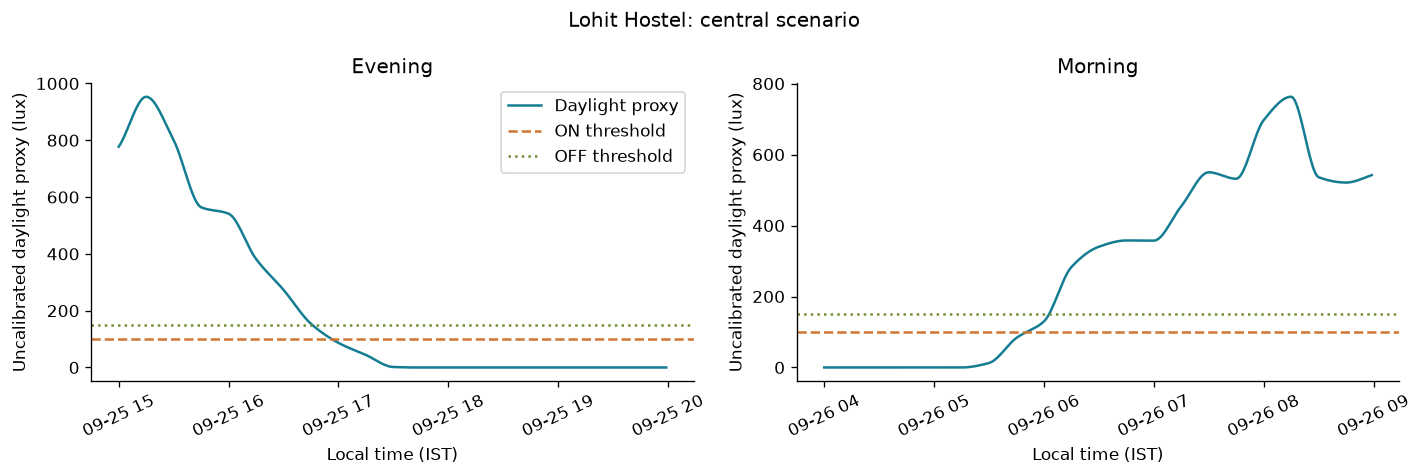

manual_on_local          2026-09-25 17:00:00+05:30
manual_off_local         2026-09-26 05:45:00+05:30
recommended_on_local     2026-09-25 16:55:00+05:30
recommended_off_local    2026-09-26 06:05:00+05:30
Name: 25, dtype: object

In [4]:
LOCATION_ID = 'LOC009'  # Lohit Hostel corridor
NIGHT = '2026-09-25'
SCENARIO = 'central'
selected = schedules[(schedules.location_id==LOCATION_ID)&(schedules.night_start_date==NIGHT)&(schedules.scenario==SCENARIO)].iloc[0]
p = profiles[(profiles.observation_id==selected.observation_id)&(profiles.scenario==SCENARIO)]
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, mask, label in [(axes[0],p.timestamp_local.dt.hour.between(15,19),'Evening'),
                         (axes[1],p.timestamp_local.dt.hour.between(4,8),'Morning')]:
    q = p[mask]
    ax.plot(q.timestamp_local.dt.tz_localize(None),q.lux_proxy,label='Daylight proxy',color='#147d92')
    ax.axhline(selected.on_threshold_lux,color='#d07532',linestyle='--',label='ON threshold')
    ax.axhline(selected.off_threshold_lux,color='#718e38',linestyle=':',label='OFF threshold')
    ax.set(title=label,ylabel='Uncalibrated daylight proxy (lux)',xlabel='Local time (IST)')
    ax.tick_params(axis='x',rotation=25)
axes[0].legend()
fig.suptitle(f'{selected.location_name}: {SCENARIO.replace("_"," ")} scenario')
fig.tight_layout()
fig.savefig(ROOT/'reports/figures/daylight_scenario.png')
plt.show()
display(selected[['manual_on_local','manual_off_local','recommended_on_local','recommended_off_local']])


## 4. Energy: excess, added and net

Use the same working-light count for manual and proposed intervals. Calculate their exact overlap:

- Excess ON hours = manual hours outside the proposed interval.
- Added ON hours = proposed hours outside the manual interval.
- Energy = hours × working fixtures × watts / 1000.
- Net savings = excess energy − added energy = manual energy − proposed energy.

Added hours identify where this **scenario** would request more lighting; they do not prove actual underlighting. Negative net savings are retained. A safety-oriented correction can increase energy consumption. Bounds reflect occasional failure-count estimates, not measured night-specific failures.

,scenario,working_count_case,manual_kwh,recommended_kwh,excess_kwh,additional_kwh,net_savings_kwh,net_savings_percent
0,central,max,3766.965,3658.026,138.099,29.160,108.939,2.892
1,central,min,3745.755,3637.844,137.072,29.160,107.912,2.881
2,higher_daylight,max,3766.965,3596.960,170.005,0.000,170.005,4.513
3,higher_daylight,min,3745.755,3576.839,168.916,0.000,168.916,4.510
4,lower_daylight,max,3766.965,3792.154,120.626,145.815,-25.189,-0.669
5,lower_daylight,min,3745.755,3771.826,119.699,145.770,-26.071,-0.696


,manual_kwh,recommended_kwh,excess_kwh,additional_kwh,net_savings_kwh,location_name
location_id,,,,,,
LOC001,2019.600,1925.880,93.720,0.00,93.720,IITG Border Road
LOC002,339.660,324.786,14.874,0.00,14.874,Surjyamukhi Road
LOC003,114.480,104.616,9.864,0.00,9.864,IIT Road
LOC004,179.010,171.171,7.839,0.00,7.839,Radhasura Road
LOC005,85.500,83.391,2.109,0.00,2.109,Godhuli Gopal Road
LOC006,29.835,28.372,1.462,0.00,1.462,Umiam Hostel Road
LOC007,64.260,61.446,2.814,0.00,2.814,KV Road
LOC008,87.210,82.821,4.389,0.00,4.389,Disang Road
LOC009,367.200,380.160,0.000,12.96,-12.960,Lohit Hostel


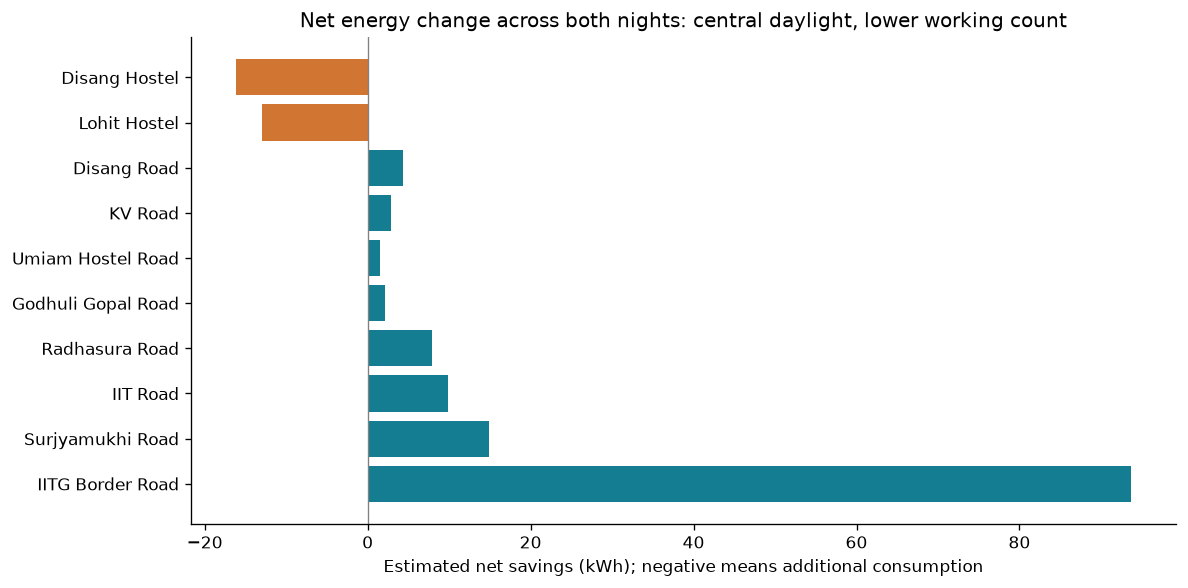

In [5]:
display(totals.round(3))
central = impacts[(impacts.scenario=='central')&(impacts.working_count_case=='min')]
by_location = central.groupby('location_id')[['manual_kwh','recommended_kwh','excess_kwh','additional_kwh','net_savings_kwh']].sum()
locations = pd.read_parquet(ROOT/'data/processed/locations.parquet').set_index('location_id')
by_location = by_location.join(locations.location_name)
display(by_location.round(3))
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(by_location.location_name,by_location.net_savings_kwh,
        color=['#147d92' if v>=0 else '#d07532' for v in by_location.net_savings_kwh])
ax.axvline(0,color='grey',linewidth=.8)
ax.set(title='Net energy change across both nights: central daylight, lower working count',
       xlabel='Estimated net savings (kWh); negative means additional consumption')
fig.tight_layout()
fig.savefig(ROOT/'reports/figures/net_energy_impact.png')
plt.show()


## 5. Cost and carbon

No verified campus tariff or current applicable grid emission factor has been supplied. These stay unset in the exported results rather than silently using example values.

Set `electricity_tariff_inr_per_kwh` and `grid_emission_factor_kg_co2_per_kwh` in `config/project_config.json`, record their source in the project notes, then rerun this notebook. The dashboard also provides explicitly illustrative rate inputs for demonstration.

Cost saved = net kWh × tariff. Avoided CO₂ = net kWh × kg CO₂/kWh. These are accounting estimates, not marginal grid-impact measurements. Negative values mean added cost/emissions.

In [6]:
net = float(central.net_savings_kwh.sum())
tariff = cfg['electricity_tariff_inr_per_kwh']
carbon = cfg['grid_emission_factor_kg_co2_per_kwh']
print(f'Central scenario net energy saving across both nights: {net:.3f} kWh')
print('Cost saved:', 'Pending documented tariff' if tariff is None else f'INR {net*tariff:.2f}')
print('Avoided CO2:', 'Pending documented emission factor' if carbon is None else f'{net*carbon:.3f} kg CO2')


Central scenario net energy saving across both nights: 107.912 kWh
Cost saved: Pending documented tariff
Avoided CO2: Pending documented emission factor


## 6. Verify accounting and edge cases

These tests check identical schedules, shorter schedules, underlighting corrections that add energy, shifted intervals with both added/excess energy, zero working fixtures, solar-event guards, a site that never reaches its OFF threshold, non-quarter-hour decisions and morning bright spikes followed by darkness.

In [7]:
import unittest
suite = unittest.defaultTestLoader.discover(str(ROOT/'tests'),pattern='test_lighting.py')
result = unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful()
np.testing.assert_allclose(impacts.manual_kwh-impacts.recommended_kwh,impacts.net_savings_kwh)
np.testing.assert_allclose(impacts.excess_kwh-impacts.additional_kwh,impacts.net_savings_kwh)
assert len(schedules)==20*3
assert len(impacts)==20*3*2
assert schedules.review_required.all()
assert (schedules.recommended_on_local<=schedules.sunset_local).all()
assert (schedules.recommended_off_local>=schedules.sunrise_local).all()
print('Schedule, accounting and edge-case checks passed.')


test_astronomical_guards_and_persistence (test_lighting.LightingTests.test_astronomical_guards_and_persistence) ... 

ok


test_identical_intervals_no_savings (test_lighting.LightingTests.test_identical_intervals_no_savings) ... 

ok


test_minute_decisions_do_not_add_a_full_sampling_interval (test_lighting.LightingTests.test_minute_decisions_do_not_add_a_full_sampling_interval) ... 

...

ok


test_zero_working_lights_no_savings_credit (test_lighting.LightingTests.test_zero_working_lights_no_savings_credit) ... 

ok


----------------------------------------------------------------------
Ran 9 tests in 0.041s

OK


Schedule, accounting and edge-case checks passed.


## 7. Run the demo

From a terminal in this project folder:

```powershell
python -m streamlit run app.py
```

Choose a location, observed night, daylight scenario and working-count case. The app shows ON/OFF comparisons, daylight curves, energy components and honest model results. See `docs/DEMO_GUIDE.md` for a 3-minute demo outline.

Before real deployment: verify local daylight/lux, fixture technology and power, zone coordinates, circuit grouping, local lighting requirements, and a current forecast/sensor feed. This prototype proposes timing changes; it cannot prove adequate lamp output or solve glare/failed fixtures through scheduling alone.